# Fit EMRI Tracks with SVD Phenomenology

This notebook is a pedagogical walkthrough of how to build a low-dimensional phenomenological basis using Singular Value Decomposition (SVD).

We proceed in two stages:
1. Construct and validate an SVD basis for a simple leading-order chirp template.
2. Apply the same idea to full EMRI frequency tracks generated by `get_f_fdot_fddot_back`.

The key objective is to show that a small number of basis vectors can accurately reproduce physically-motivated tracks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from multiprocess import Pool
from few.utils.constants import *
from emrisearch.emri_utils import get_f_fdot_fddot_back

np.random.seed(2601)
plt.rcParams["figure.figsize"] = (8, 4.5)

## Global Time Grid and Fiducial Source

We first define a single time grid used throughout the notebook. This keeps comparisons between the toy model and EMRI model consistent.

In [2]:
# Shared time grid
T_sft = 5e4                # seconds
T_data = 1.0               # years
num_sfts = int((T_data * YRSID_SI) / T_sft)
t_alpha = np.arange(num_sfts) * T_sft

# Fiducial EMRI parameters used for visualization
m1 = 1e6
m2 = 10.0
a = 0.99
Tpl = 1.0
ef = 0.01

print(f"Number of SFT mid-times: {num_sfts}")
print(f"Time span [years]: {(t_alpha[-1]-t_alpha[0])/YRSID_SI:.3f}")

Number of SFT mid-times: 631
Time span [years]: 0.998


## Part I: SVD on a Simple Chirp Template

We start from the analytic template

$$
f_\mathrm{gw}(t)=f_0\left(1-\frac{8}{3}k(t-t_0)f_0^{8/3}\right)^{-3/8},
$$

then build a bank of tracks, perform SVD, and test reconstruction accuracy on unseen tracks.

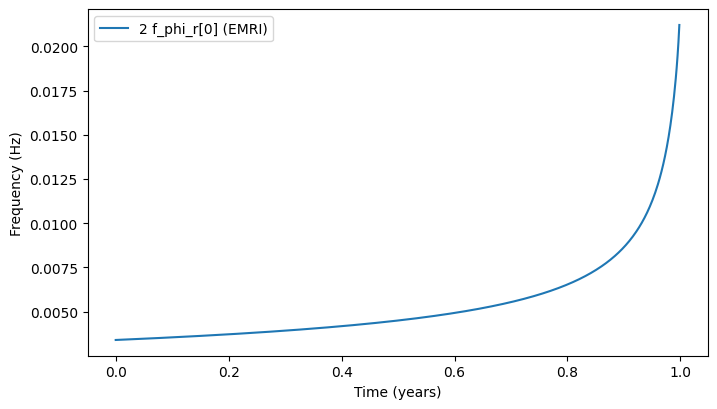

In [3]:
def template_f_of_t(t, f0, k, t0):
    fgw = f0 * (1 - 8/3 * k * (t - t0) * f0**(8/3))**(-3/8)
    fgw = np.nan_to_num(fgw, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return fgw

def tc_to_k(tc, f0):
    return 3.0 / (8.0 * tc * f0**(8.0 / 3.0))

def make_template_bank(t, f0_values, tc_values, t0=0.0):
    tracks = []
    params = []
    for f0 in f0_values:
        for tc in tc_values:
            k = tc_to_k(tc, f0)
            tracks.append(template_f_of_t(t, f0, k, t0))
            params.append((f0, k, tc))
    return np.asarray(tracks), np.asarray(params)

# quick sanity plot of one fiducial EMRI mode for context
true_values = np.array([m1, m2, a, Tpl, ef, 1.0])
phi, f_phi_r, dotf, dotdotf = get_f_fdot_fddot_back(true_values, t_alpha)
plt.plot(t_alpha / YRSID_SI, 2 * f_phi_r[0], label="2 f_phi_r[0] (EMRI)")
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.show()

### Build Training and Validation Banks

We construct a grid of simple chirp tracks for training, and an independent random bank for validation.

Toy training bank shape: (396, 631)
Toy validation bank shape: (200, 631)


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_23514/869343716.py:2: RuntimeWarning: invalid value encountered in power
  fgw = f0 * (1 - 8/3 * k * (t - t0) * f0**(8/3))**(-3/8)


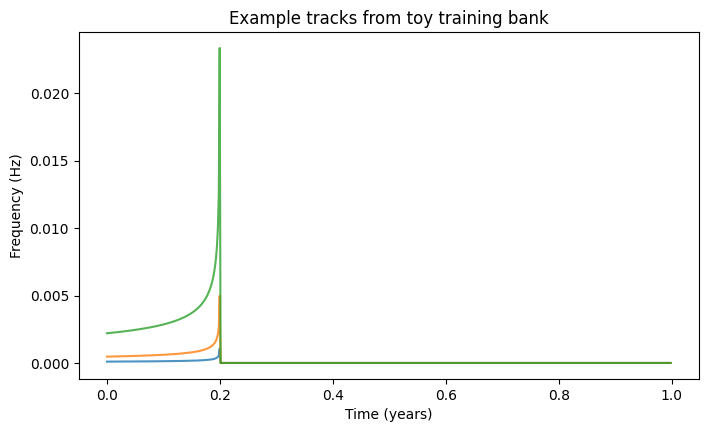

In [4]:
# Training bank (grid)
f0_grid = np.logspace(np.log10(1e-4), np.log10(8e-3), 18)
tc_grid = np.linspace(0.2, 4.0, 22) * YRSID_SI
toy_train, toy_train_params = make_template_bank(t_alpha, f0_grid, tc_grid)

# Validation bank (random)
rng = np.random.default_rng(2601)
n_val = 200
f0_val = 10**rng.uniform(np.log10(1e-4), np.log10(8e-3), size=n_val)
tc_val = rng.uniform(0.2, 4.0, size=n_val) * YRSID_SI
toy_val = np.asarray([
    template_f_of_t(t_alpha, f0, tc_to_k(tc, f0), 0.0)
    for f0, tc in zip(f0_val, tc_val)
])

print("Toy training bank shape:", toy_train.shape)
print("Toy validation bank shape:", toy_val.shape)

for i in [0, len(toy_train)//3, 2*len(toy_train)//3]:
    plt.plot(t_alpha / YRSID_SI, toy_train[i], alpha=0.8)
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.title("Example tracks from toy training bank")
plt.show()

Toy bank rank: 396
Modes for 90% energy: 3
Modes for 99% energy: 6


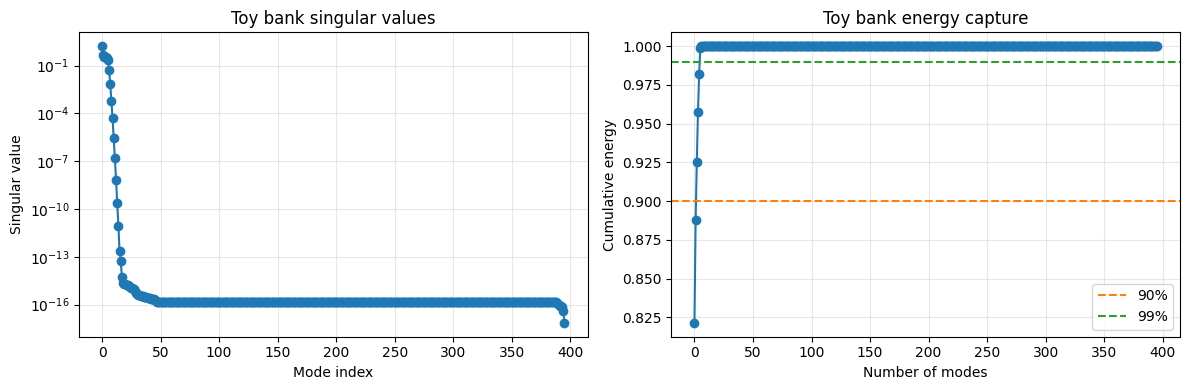

In [5]:
# SVD of toy bank
U_toy, S_toy, Vt_toy = np.linalg.svd(toy_train, full_matrices=False)

energy_fraction = np.cumsum(S_toy**2) / np.sum(S_toy**2)
k90 = np.searchsorted(energy_fraction, 0.90) + 1
k99 = np.searchsorted(energy_fraction, 0.99) + 1

print(f"Toy bank rank: {len(S_toy)}")
print(f"Modes for 90% energy: {k90}")
print(f"Modes for 99% energy: {k99}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(S_toy, "o-")
ax1.set_xlabel("Mode index")
ax1.set_ylabel("Singular value")
ax1.set_title("Toy bank singular values")
ax1.grid(alpha=0.3)

ax2.plot(energy_fraction, "o-")
ax2.axhline(0.90, color="tab:orange", linestyle="--", label="90%")
ax2.axhline(0.99, color="tab:green", linestyle="--", label="99%")
ax2.set_xlabel("Number of modes")
ax2.set_ylabel("Cumulative energy")
ax2.set_title("Toy bank energy capture")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

Toy validation median relative error with  3 modes: 5.195e-02
Toy validation median relative error with  5 modes: 2.674e-02
Toy validation median relative error with  8 modes: 3.928e-04
Toy validation median relative error with 12 modes: 5.549e-09


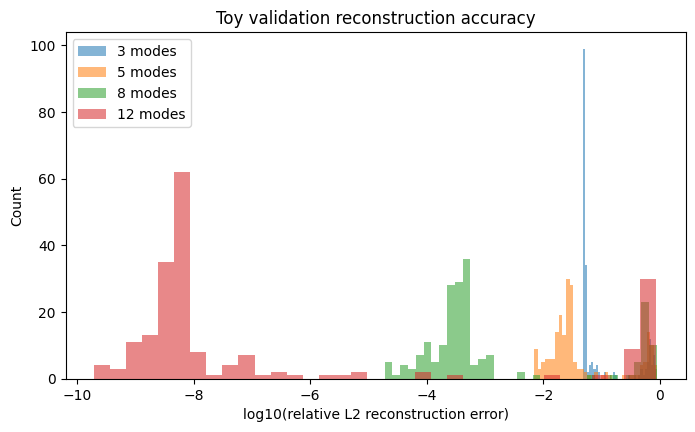

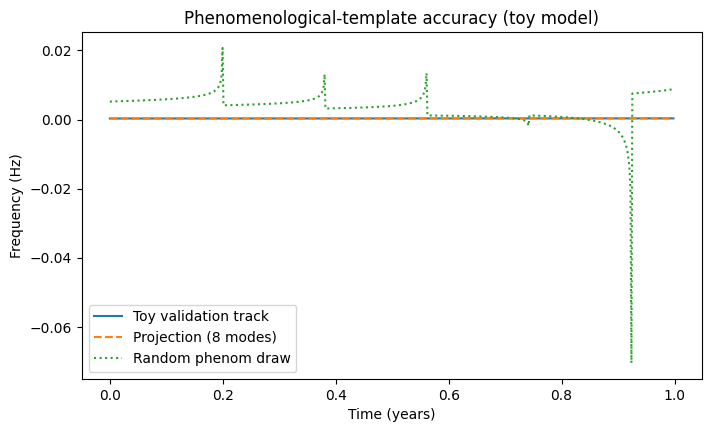

In [6]:
def reconstruct_from_basis(x, Vt, n_modes):
    basis = Vt[:n_modes]
    coeffs = x @ basis.T
    return coeffs @ basis, coeffs

modes_to_test = [3, 5, 8, 12]
toy_rel_err = {}

for n_modes in modes_to_test:
    toy_rec, toy_coeff = reconstruct_from_basis(toy_val, Vt_toy, n_modes)
    rel = np.linalg.norm(toy_val - toy_rec, axis=1) / np.linalg.norm(toy_val, axis=1)
    toy_rel_err[n_modes] = rel
    print(f"Toy validation median relative error with {n_modes:2d} modes: {np.median(rel):.3e}")

plt.figure()
for n_modes in modes_to_test:
    plt.hist(np.log10(toy_rel_err[n_modes]), bins=35, alpha=0.55, label=f"{n_modes} modes")
plt.xlabel("log10(relative L2 reconstruction error)")
plt.ylabel("Count")
plt.title("Toy validation reconstruction accuracy")
plt.legend()
plt.show()

# Demonstrate phenomenological template generation from SVD coefficients
n_modes_demo = 8
toy_basis = Vt_toy[:n_modes_demo]
toy_min_csi = (U_toy[:, :n_modes_demo] * S_toy[:n_modes_demo]).min(axis=0) / S_toy[:n_modes_demo]
toy_max_csi = (U_toy[:, :n_modes_demo] * S_toy[:n_modes_demo]).max(axis=0) / S_toy[:n_modes_demo]

def toy_phenom_template(csi):
    return (csi * S_toy[:n_modes_demo]) @ toy_basis

idx = 5
target = toy_val[idx]
target_proj, target_coeff = reconstruct_from_basis(target[None, :], Vt_toy, n_modes_demo)

random_csi = rng.uniform(toy_min_csi, toy_max_csi, size=n_modes_demo)
random_track = toy_phenom_template(random_csi)

plt.figure()
plt.plot(t_alpha / YRSID_SI, target, label="Toy validation track")
plt.plot(t_alpha / YRSID_SI, target_proj[0], "--", label=f"Projection ({n_modes_demo} modes)")
plt.plot(t_alpha / YRSID_SI, random_track, ":", label="Random phenom draw")
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.title("Phenomenological-template accuracy (toy model)")
plt.legend()
plt.show()

## Part II: Apply the Same SVD Workflow to EMRI Tracks

Now we replace the analytic toy tracks with physically-generated EMRI tracks and repeat the same workflow:
1. Build a training bank.
2. Compute SVD.
3. Quantify reconstruction quality on held-out tracks.
4. Interpret phenomenological coefficients.

In [7]:
def get_f_fdot_fddot_back_wrapper(params):
    try:
        return get_f_fdot_fddot_back(params, t_alpha)
    except Exception:
        return None

# Build EMRI training bank
n_emri_train = 512
delta_Tpl = 1e-16
Tpl_max = 1.0

bounds = np.asarray([
    (5.0, 7.0),                             # log10(m1)
    (1.0, 120.0),                           # m2
    (0.0, 0.998),                           # a
    (Tpl_max - delta_Tpl, Tpl_max + delta_Tpl),
    (0.0, 0.2),                             # ef
    (Tpl_max - delta_Tpl, Tpl_max + delta_Tpl),
], dtype=float)

random_params = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_emri_train, bounds.shape[0]))
random_params[:, 0] = 10**random_params[:, 0]
random_params[:, 3] = Tpl_max
random_params[:, -1] = 1.0

with Pool() as pool:
    out = pool.starmap(get_f_fdot_fddot_back_wrapper, [(p,) for p in random_params])

valid_mask = np.array([el is not None for el in out])
random_params_valid = random_params[valid_mask]
fs = np.array([el[1] for el in out if el is not None])

emri_train = 2.0 * fs[:, 0]
nonzero_mask = emri_train[:, 0] != 0.0
emri_train = emri_train[nonzero_mask]
random_params_valid = random_params_valid[nonzero_mask]

print("EMRI training bank shape:", emri_train.shape)

EMRI training bank shape: (461, 631)


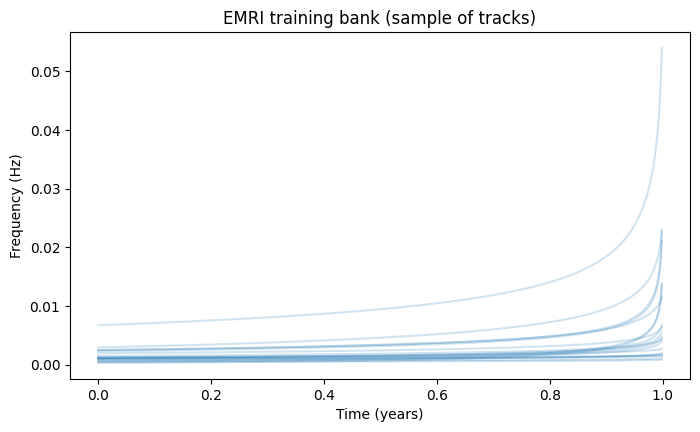

In [8]:
plt.figure()
for i in np.linspace(0, len(emri_train) - 1, 20, dtype=int):
    plt.plot(t_alpha / YRSID_SI, emri_train[i], alpha=0.20, color="tab:blue")
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.title("EMRI training bank (sample of tracks)")
plt.show()

EMRI bank rank: 461
EMRI modes for 90% energy: 1
EMRI modes for 99% energy: 2


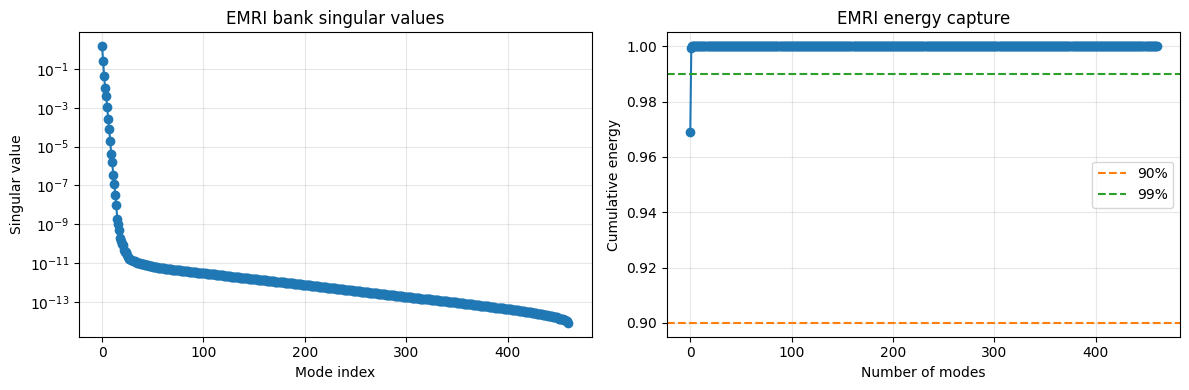

In [9]:
# SVD of EMRI training bank
U_emri, S_emri, Vt_emri = np.linalg.svd(emri_train, full_matrices=False)
energy_emri = np.cumsum(S_emri**2) / np.sum(S_emri**2)

k90_emri = np.searchsorted(energy_emri, 0.90) + 1
k99_emri = np.searchsorted(energy_emri, 0.99) + 1

print(f"EMRI bank rank: {len(S_emri)}")
print(f"EMRI modes for 90% energy: {k90_emri}")
print(f"EMRI modes for 99% energy: {k99_emri}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(S_emri, "o-")
ax1.set_xlabel("Mode index")
ax1.set_ylabel("Singular value")
ax1.set_title("EMRI bank singular values")
ax1.grid(alpha=0.3)

ax2.plot(energy_emri, "o-")
ax2.axhline(0.90, color="tab:orange", linestyle="--", label="90%")
ax2.axhline(0.99, color="tab:green", linestyle="--", label="99%")
ax2.set_xlabel("Number of modes")
ax2.set_ylabel("Cumulative energy")
ax2.set_title("EMRI energy capture")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

EMRI validation median relative error with  3 modes: 6.159e-03
EMRI validation median relative error with  5 modes: 7.505e-04
EMRI validation median relative error with  8 modes: 6.320e-06
EMRI validation median relative error with 12 modes: 4.397e-08
EMRI validation median relative error with 20 modes: 5.053e-11


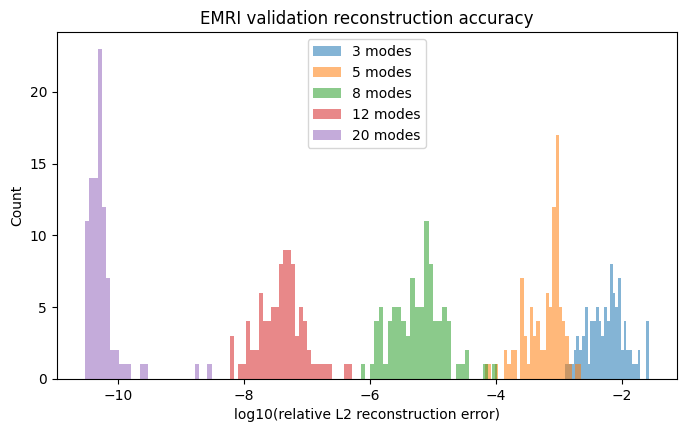

In [10]:
# Hold-out split for EMRI validation
n_holdout = max(20, len(emri_train) // 5)
perm = rng.permutation(len(emri_train))
val_idx = perm[:n_holdout]
tr_idx = perm[n_holdout:]

emri_train_small = emri_train[tr_idx]
emri_val = emri_train[val_idx]

# Recompute basis on reduced train set for fair validation
U_emri_t, S_emri_t, Vt_emri_t = np.linalg.svd(emri_train_small, full_matrices=False)

modes_to_test_emri = [3, 5, 8, 12, 20]
emri_rel_err = {}

for n_modes in modes_to_test_emri:
    emri_rec, _ = reconstruct_from_basis(emri_val, Vt_emri_t, n_modes)
    rel = np.linalg.norm(emri_val - emri_rec, axis=1) / np.linalg.norm(emri_val, axis=1)
    emri_rel_err[n_modes] = rel
    print(f"EMRI validation median relative error with {n_modes:2d} modes: {np.median(rel):.3e}")

plt.figure()
for n_modes in modes_to_test_emri:
    plt.hist(np.log10(emri_rel_err[n_modes]), bins=30, alpha=0.55, label=f"{n_modes} modes")
plt.xlabel("log10(relative L2 reconstruction error)")
plt.ylabel("Count")
plt.title("EMRI validation reconstruction accuracy")
plt.legend()
plt.show()

In [11]:
# Coefficient ranges in reduced EMRI basis
n_modes_emri_demo = 12
W_emri = U_emri_t[:, :n_modes_emri_demo] * S_emri_t[:n_modes_emri_demo]
csi_emri = W_emri / S_emri_t[:n_modes_emri_demo]

csi_min = csi_emri.min(axis=0)
csi_max = csi_emri.max(axis=0)

print("csi range shape:", csi_min.shape)
print("First 5 csi intervals:")
for i in range(min(5, n_modes_emri_demo)):
    print(f"  mode {i}: [{csi_min[i]: .3e}, {csi_max[i]: .3e}]")

csi range shape: (12,)
First 5 csi intervals:
  mode 0: [ 7.077e-03,  3.040e-01]
  mode 1: [-2.069e-01,  2.501e-01]
  mode 2: [-2.696e-01,  1.989e-01]
  mode 3: [-2.984e-01,  3.270e-01]
  mode 4: [-3.196e-01,  3.942e-01]


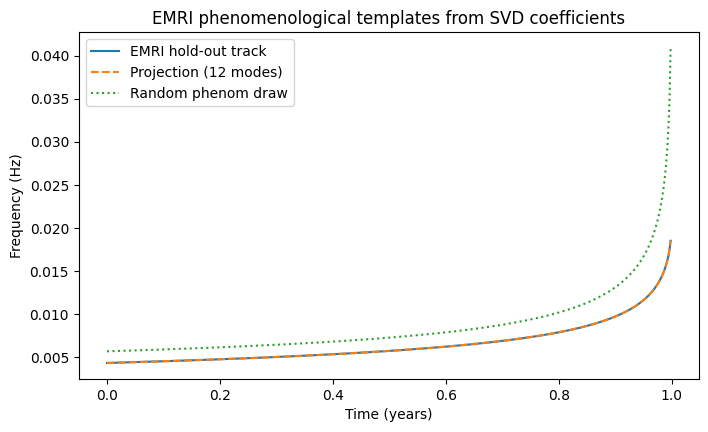

In [12]:
def emri_phenom_template(csi):
    return (csi * S_emri_t[:n_modes_emri_demo]) @ Vt_emri_t[:n_modes_emri_demo]

# Pick one hold-out track and project it onto the reduced basis
idx = 0
target = emri_val[idx]
target_rec, target_coeff = reconstruct_from_basis(target[None, :], Vt_emri_t, n_modes_emri_demo)

# Draw random phenomenological coefficients within training range
csi_rand = rng.uniform(csi_min, csi_max, size=n_modes_emri_demo)
rand_track = emri_phenom_template(csi_rand)

plt.figure()
plt.plot(t_alpha / YRSID_SI, target, label="EMRI hold-out track")
plt.plot(t_alpha / YRSID_SI, target_rec[0], "--", label=f"Projection ({n_modes_emri_demo} modes)")
plt.plot(t_alpha / YRSID_SI, rand_track, ":", label="Random phenom draw")
plt.xlabel("Time (years)")
plt.ylabel("Frequency (Hz)")
plt.title("EMRI phenomenological templates from SVD coefficients")
plt.legend()
plt.show()

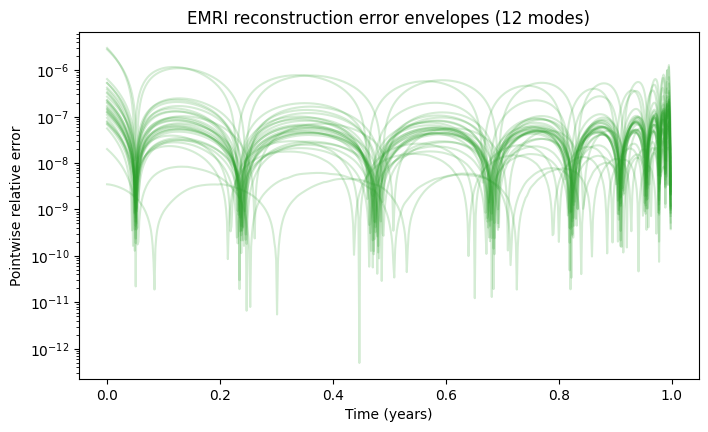

EMRI reduced model (n=12) median relative L2 error: 4.397e-08
EMRI reduced model (n=12) 90th percentile error: 9.481e-08


In [13]:
# Pointwise relative errors for several hold-out examples
n_show = min(30, len(emri_val))
plt.figure()
for i in range(n_show):
    rec_i, _ = reconstruct_from_basis(emri_val[i:i+1], Vt_emri_t, n_modes_emri_demo)
    rel_t = np.abs(1.0 - rec_i[0] / np.maximum(emri_val[i], 1e-30))
    plt.semilogy(t_alpha / YRSID_SI, rel_t, alpha=0.20, color="tab:green")
plt.xlabel("Time (years)")
plt.ylabel("Pointwise relative error")
plt.title(f"EMRI reconstruction error envelopes ({n_modes_emri_demo} modes)")
plt.show()

# Aggregate error summary
rel_all = []
for i in range(len(emri_val)):
    rec_i, _ = reconstruct_from_basis(emri_val[i:i+1], Vt_emri_t, n_modes_emri_demo)
    rel_all.append(np.linalg.norm(emri_val[i] - rec_i[0]) / np.linalg.norm(emri_val[i]))
rel_all = np.array(rel_all)

print(f"EMRI reduced model (n={n_modes_emri_demo}) median relative L2 error: {np.median(rel_all):.3e}")
print(f"EMRI reduced model (n={n_modes_emri_demo}) 90th percentile error: {np.percentile(rel_all, 90):.3e}")

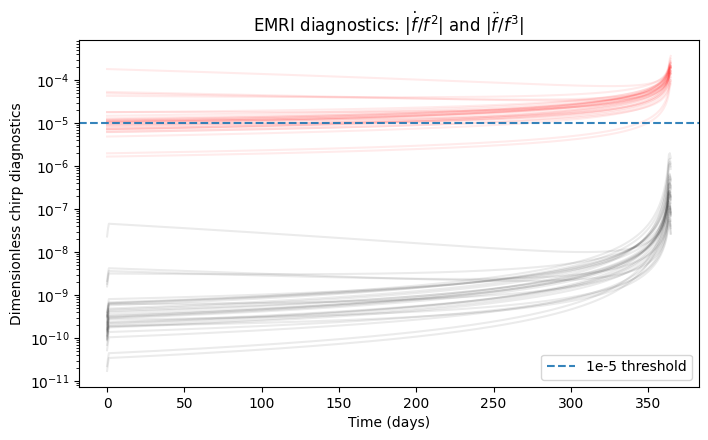

In [14]:
# Optional diagnostic: slow-chirp indicators on EMRI tracks
dt = T_sft
dotf_num = np.gradient(emri_train, dt, axis=1)
ddotf_num = np.gradient(dotf_num, dt, axis=1)

ratio_dot = np.abs(dotf_num / np.maximum(emri_train, 1e-30)**2)
ratio_ddot = np.abs(ddotf_num / np.maximum(emri_train, 1e-30)**3)

plt.figure(figsize=(8, 4.5))
for i in np.linspace(0, len(emri_train) - 1, 30, dtype=int):
    plt.semilogy(t_alpha / 86400.0, ratio_ddot[i], color="k", alpha=0.08)
    plt.semilogy(t_alpha / 86400.0, ratio_dot[i], color="r", alpha=0.08)
plt.axhline(y=1e-5, color="tab:blue", linestyle="--", alpha=0.9, label="1e-5 threshold")
plt.xlabel("Time (days)")
plt.ylabel("Dimensionless chirp diagnostics")
plt.title(r"EMRI diagnostics: $|\dot f/f^2|$ and $|\ddot f/f^3|$")
plt.legend()
plt.show()

In [15]:
print("Summary")
print("-------")
print("1) A small SVD basis accurately reproduces the simple chirp template bank.")
print("2) The same reduced-basis strategy transfers to EMRI tracks.")
print("3) Phenomenological templates are generated by sampling reduced coefficients csi.")
print("4) Validation errors quantify how many modes are needed for your target accuracy.")

Summary
-------
1) A small SVD basis accurately reproduces the simple chirp template bank.
2) The same reduced-basis strategy transfers to EMRI tracks.
3) Phenomenological templates are generated by sampling reduced coefficients csi.
4) Validation errors quantify how many modes are needed for your target accuracy.
